In [2]:
import sys, os
import pickle as pk
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from models import *

sys.path.append("../")
from sangrah.tools import get_info

sys.path.append('../../scripts_analysis')
from analysis import *

In [3]:
resultPath = "../../data/control/"

dirs = [a for a in getDirs(resultPath, sstr='nVDCC')]# if "bISI" in a]
dirs = np.array(dirs)

d = 'nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10'
d = dirs[43]
print('Directory: ', d)
dirs

Directory:  nVDCC_10_dVAZ_160_nAZ_9_RRP_45_ISI_20_nAP_10


array(['nVDCC_10_dVAZ_100_nAZ_13_RRP_5_ISI_20_nAP_10',
       'nVDCC_10_dVAZ_100_nAZ_7_RRP_10_ISI_20_nAP_10',
       'nVDCC_10_dVAZ_120_nAZ_11_RRP_10_ISI_20_nAP_10', ...,
       'nVDCC_9_dVAZ_220_nAZ_33_RRP_15_ISI_20_nAP_10',
       'nVDCC_9_dVAZ_220_nAZ_33_RRP_20_ISI_20_nAP_10',
       'nVDCC_9_dVAZ_220_nAZ_35_RRP_15_ISI_20_nAP_10'],
      shape=(1411,), dtype='<U45')

In [4]:
resultDir = os.path.join(resultPath, d)
simInfo = get_info(d, skip=0)
ISI, nAP, RRP = int(simInfo['ISI']), int(simInfo['nAP']), simInfo['RRP']

inf = os.path.join(resultDir, 'vesData.dat')
with open(inf, "rb") as infile:
    vesData = pk.load(infile)

seeds = len(vesData[RRP])

In [19]:
def get_spike_generator_info(spikes):
    spid, sptimes = [], []
    for i, spike in enumerate(spikes):
        # print(spike, len(spike))
        spid += np.full((len(spike)), i).tolist()
        sptimes += spike

    return len(spikes), spid, [float(a) for a in sptimes]
    

nMFB, spid, sptimes = get_spike_generator_info(vesData[RRP][:5])
# nMFB, spid, sptimes

In [20]:
defaultclock.dt = 0.1*ms
start_scope()

MFBvrel = SpikeGeneratorGroup(nMFB, spid, sptimes*second)

nCA3p = nMFB
CA3p = NeuronGroup(nCA3p, eqnCA3_PR, 
                   method='exponential_euler', 
                   threshold='Vs>0*mV', 
                   refractory='Vs>0*mV', 
                   namespace=CA3p_PR_params)
CA3p.Vd = -64.26496446 * mV
CA3p.Vs = -64.36594952 * mV

# Synapse: MFB to CA3 pyramidal neuron
MFB_CA3p_syn = Synapses(MFBvrel, CA3p,
                        model=eqs_MFB_CA3p_syn,
                        on_pre=MFB_CA3p_onpre,
                        method='exponential_euler',
                        namespace=MFB_CA3p_syn_params)
MFB_CA3p_syn.connect(j='i')

# Monitors
stMCA3p = StateMonitor(CA3p, ['Vd', 'Vs', 'Isyn'], record=True)
spMCA3p = SpikeMonitor(CA3p)

# Run the simulation
run(210 * ms)

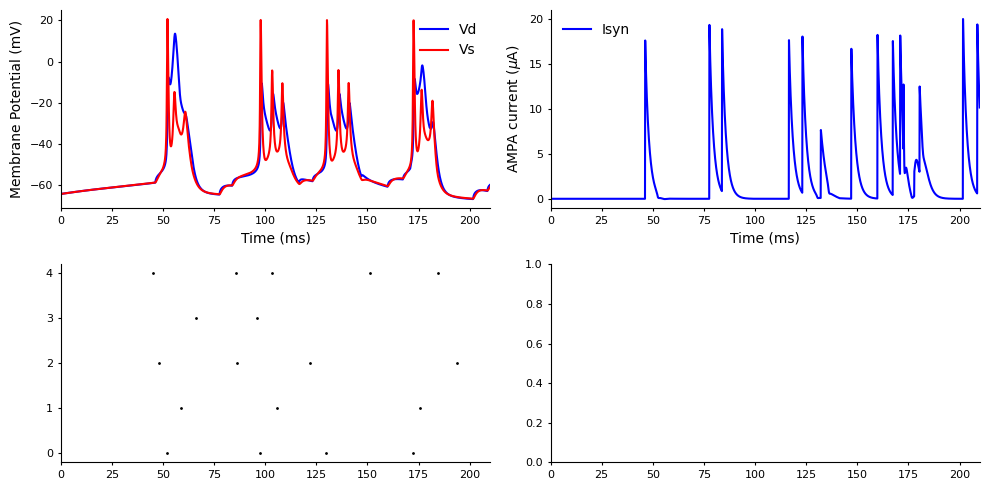

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.2, hspace=0.15)
# fig.suptitle("Simulation Results")

## Plot the CA3 spikes
axes[0,0].plot(stMCA3p.t/ms, stMCA3p.Vd[0]/mV, 'b-', label='Vd')
axes[0,0].plot(stMCA3p.t/ms, stMCA3p.Vs[0]/mV, 'r-', label='Vs')
axes[0,0].set_xlabel("Time (ms)")
axes[0,0].set_ylabel("Membrane Potential (mV)")
axes[0,0].legend(frameon=False)

## Plot the synaptic current
axes[0,1].plot(stMCA3p.t/ms, -stMCA3p.Isyn[0]/uA, 'b-', label='Isyn')
axes[0,1].set_xlabel("Time (ms)")
axes[0,1].set_ylabel(r"AMPA current ($\mu$A)")
axes[0,1].legend(frameon=False)

## Raster plot of the CA3 spikes
axes[1,0].plot(spMCA3p.t/ms, spMCA3p.i, 'k.', markersize=2)

## Raster plot of the MFB vesicle releases
for i in range(nMFB):
    pass#axes[1,1].eventplot(sptimes[i], 'k.', markersize=2)

for ax in axes.ravel():
    # ax.set_xlim(0, runt)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis=u'both', which=u'both', length=2, labelsize=8)
    ax.set_xlim(0, 210)

plt.tight_layout()
plt.show()

In [32]:
[a/ms for a in spMCA3p.spike_trains().values()]

[array([ 51.9,  97.5, 129.9, 172.3]),
 array([ 58.9, 105.8, 175.7]),
 array([ 47.9,  86. , 122.1, 193.9]),
 array([66.1, 95.9]),
 array([ 45.2,  85.6, 103.5, 151.4, 184.4])]